<a href="https://colab.research.google.com/github/tetianaboyko3/Python-practice/blob/main/Tetiana_Boiko_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [ ]:
import matplotlib.dates as mdates

In [ ]:
monthly_stats = df.groupby('month_year')['count'].agg(['mean', 'std', 'count'])

# Довірчий інтервал = 1 стандартне відхилення (як зазначено в завданні)
monthly_stats['ci_upper'] = monthly_stats['mean'] + monthly_stats['std']
monthly_stats['ci_lower'] = monthly_stats['mean'] - monthly_stats['std']

# Створення індексу дати для коректного відображення на графіку
monthly_stats.index = pd.to_datetime(monthly_stats.index)


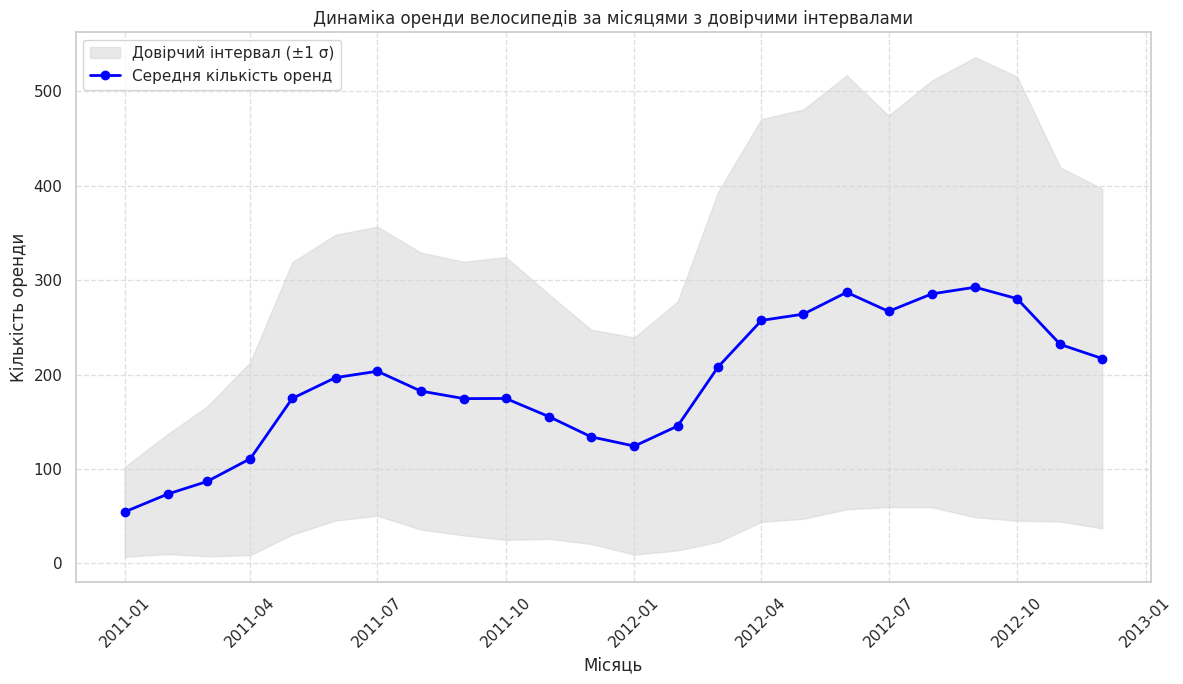

In [ ]:
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Заливка області довірчого інтервалу (± 1 стандартне відхилення)
plt.fill_between(monthly_stats.index,
                 monthly_stats['ci_lower'],
                 monthly_stats['ci_upper'],
                 color='lightgrey', alpha=0.5, label='Довірчий інтервал (±1 σ)')

# Побудова основної лінії середнього значення
plt.plot(monthly_stats.index, monthly_stats['mean'], color='blue', marker='o',
         linestyle='-', linewidth=2, label='Середня кількість оренд')

# Налаштування графіка
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Форматування осі X для відображення місяць-рік та поворот міток
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


✅ ***Висновок:***

Найбільша невизначеність в даних спостерігається в літні та осінні місяці, зокрема в період з червня по жовтень 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

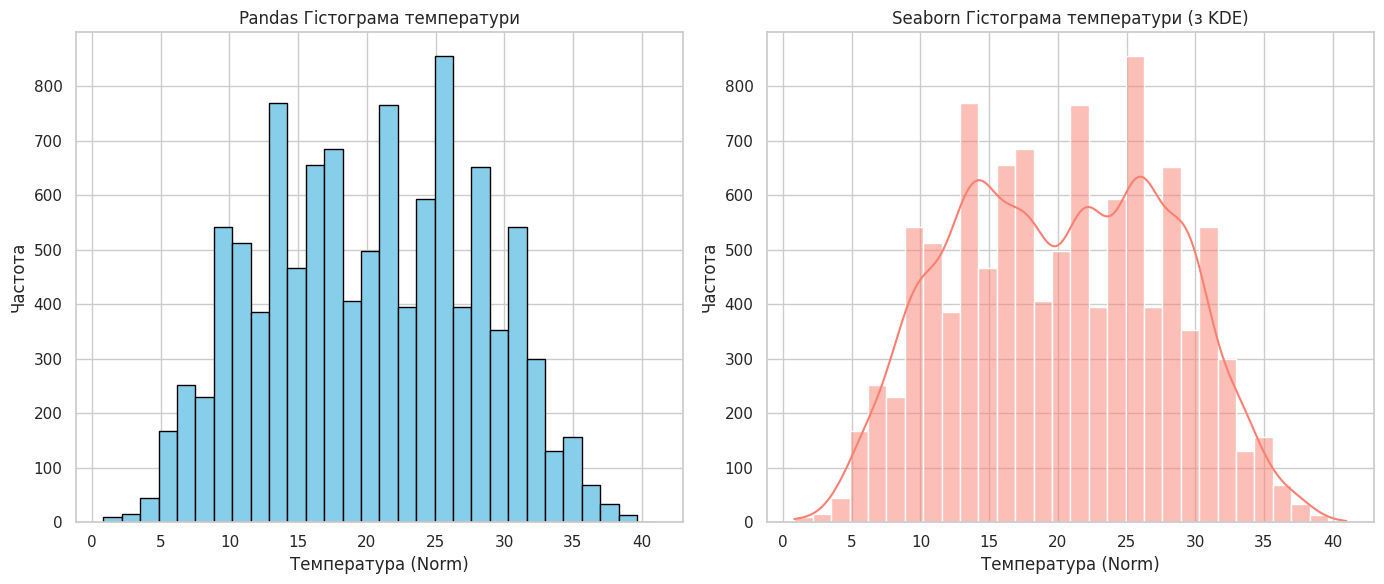

In [ ]:
# Визначення однакової кількості бінів, відмінної від стандартної
N_BINS = 30

# Створення однієї фігури з двома підграфіками поруч
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# --- 1. Візуалізація за допомогою Pandas ---
# Pandas використовує ax=axes[0] для вказівки, де малювати
df['temp'].hist(ax=axes[0], bins=N_BINS, color='skyblue', edgecolor='black')
axes[0].set_title('Pandas Гістограма температури')
axes[0].set_xlabel('Температура (Norm)')
axes[0].set_ylabel('Частота')

# --- 2. Візуалізація за допомогою Seaborn ---
# Seaborn також використовує ax=axes[1]
sns.histplot(df['temp'], ax=axes[1], bins=N_BINS, kde=True, color='salmon')
axes[1].set_title('Seaborn Гістограма температури (з KDE)')
axes[1].set_xlabel('Температура (Norm)')
axes[1].set_ylabel('Частота') # Seaborn може автоматично підписати вісь Y

plt.tight_layout()
plt.show()


✅ ***Висновок:***

1. Візуальна різниця полягає в естетиці та деталізації:

Pandas-гістограма має базовий, простий вигляд. Це стандартний графік із прямокутними стовпцями, що демонструє розподіл даних без додаткових прикрас чи складних елементів стилю.

Seaborn-гістограма виглядає більш сучасно та інформативно. Вона має типовий стиль Seaborn (зазвичай іншу кольорову гаму за замовчуванням, прозорість, інший дизайн осей) і, що найважливіше, містить додаткову плавну лінію поверх стовпців.

2. Ця додаткова лінія називається KDE (Kernel Density Estimate), або Оцінка щільності ядра.
Це плавна крива, яка накладається на гістограму і показує узагальнену форму розподілу даних. Вона "згладжує" сходинки гістограми і допомагає краще зрозуміти загальну тенденцію, піки та провали в даних, ігноруючи шум, спричинений вибором конкретної кількості бінів (стовпців). Вона дає більш точне уявлення про те, як імовірно розподілені значення температури в генеральній сукупності.


## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

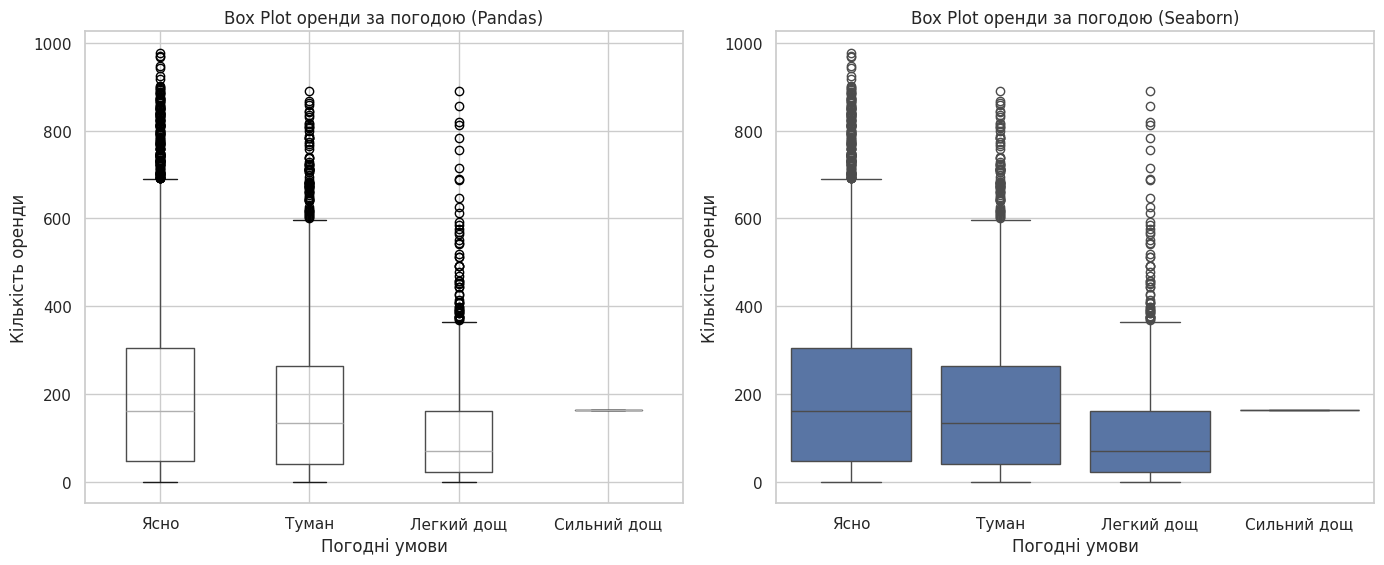

In [ ]:
weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

# Створюємо порівняльні графіки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pandas box plot
df.boxplot(column='count', by='weather', ax=ax1)
ax1.set_title('Box Plot оренди за погодою (Pandas)')
ax1.set_xlabel('Погодні умови')
ax1.set_ylabel('Кількість оренди')
ax1.set_xticklabels(weather_labels)
plt.suptitle('')  # Прибираємо автозаголовок

# Seaborn box plot
sns.boxplot(data=df, x='weather', y='count', ax=ax2, order=[1,2,3,4])
ax2.set_title('Box Plot оренди за погодою (Seaborn)')
ax2.set_xlabel('Погодні умови')
ax2.set_ylabel('Кількість оренди')

# Додаємо підписи погодних умов для Seaborn

ax2.set_xticks(range(len(weather_labels)))
ax2.set_xticklabels(weather_labels)
plt.tight_layout()
plt.show()

✅***Висновок:***

Бокс-плоти Pandas є базовими та функціональними, використовуючи стандартну естетику Matplotlib. Натомість, бокс-плоти Seaborn виглядають сучасніше та привабливіше, з кращими типовими палітрами кольорів та автоматичним форматуванням осей. Основна відмінність полягає в тому, що Seaborn краще обробляє категоризацію та стиль "із коробки", тоді як Pandas часто потребує ручних налаштувань.


<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


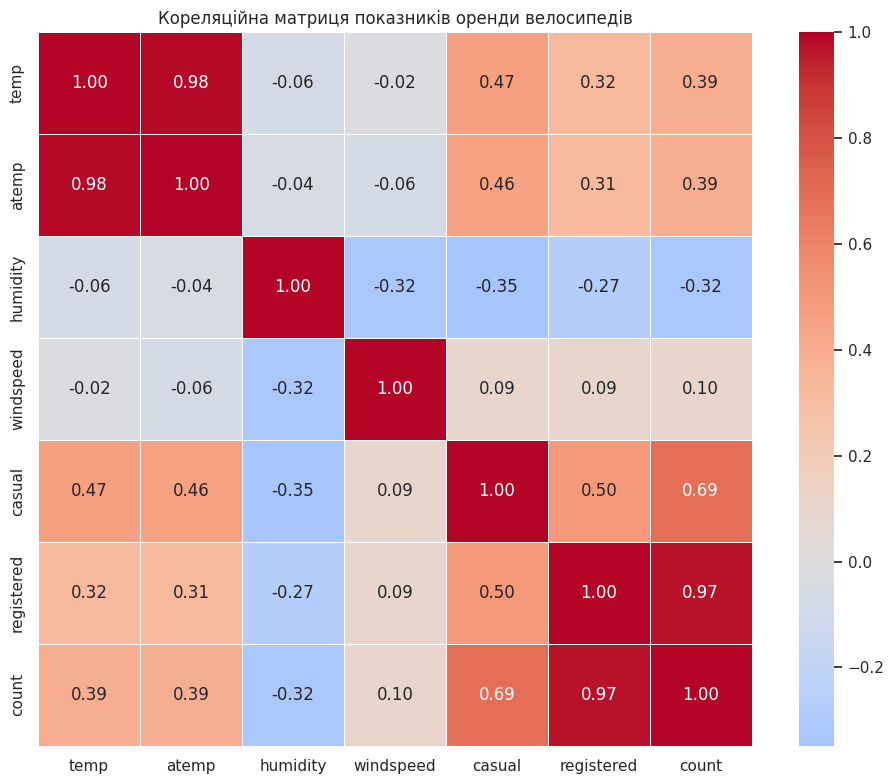

In [ ]:
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5,
            fmt='.2f')

plt.title('Кореляційна матриця показників оренди велосипедів')
plt.tight_layout()
plt.show()

✅ ***Висновок:***

1. Найсильнішу позитивну кореляцію із загальною кількістю оренди (count) мають змінні registered та casual, що логічно, оскільки загальна кількість є сумою цих двох.
2. Між temp (фактична температура) та atemp (відчутна температура) спостерігається надзвичайно сильна позитивна кореляція (0.98). Це майже ідеальна лінійна залежність.
Причина: Ці дві змінні вимірюють, по суті, один і той самий фізичний параметр — температуру повітря, лише з невеликими поправками на вологість та вітер. Тому їх значення змінюються майже синхронно.
3. Негативну кореляцію із загальною кількістю оренди (count) мають змінні humidity, weather, windspeed  та weekday_num.
Найбільш виражена негативна залежність від вологості: чим вища вологість, тим менше в середньому орендують велосипеди.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


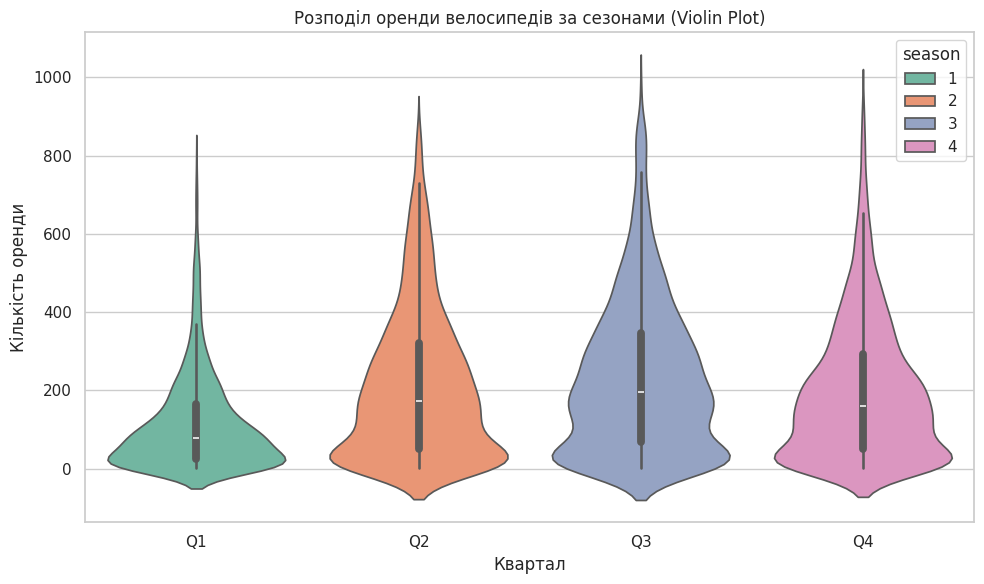

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='season', y='count', hue='season', palette='Set2')

plt.title('Розподіл оренди велосипедів за сезонами (Violin Plot)')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренди')

# Додаю назви кварталів
season_labels = ['Q1', 'Q2', 'Q3', 'Q4']
plt.xticks(range(4), season_labels)

plt.tight_layout()
plt.show()

✅ ***Висновок:***
1. Товщина violin plot показує щільність розподілу даних (частоту спостережень) у цьому конкретному діапазоні значень. Чим ширша частина графіка по вертикалі, тим більше днів або годин мало саме таку кількість оренд. По суті, це плавна візуалізація гістограми, що показує, де зосереджена основна маса даних.

2. Варіабельність найбільша, як правило, у Q2 (Весна/Літо) та Q3 (Літо/Осінь). Це квартали, де violin plot є найдовшою по вертикалі і має найбільший вертикальний розмах, що свідчить про велику різницю між мінімальною та максимальною кількістю оренд в окремі дні цих періодів.

3. Основна перевага в тому, що violin plot відображає повний розподіл даних, показуючи щільність у кожній точці, тоді як box plot показує лише ключові підсумкові статистики (медіану, квартилі, викиди). Violin plot може виявити складні розподіли (наприклад, два окремі піки активності), що box plot може приховати.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

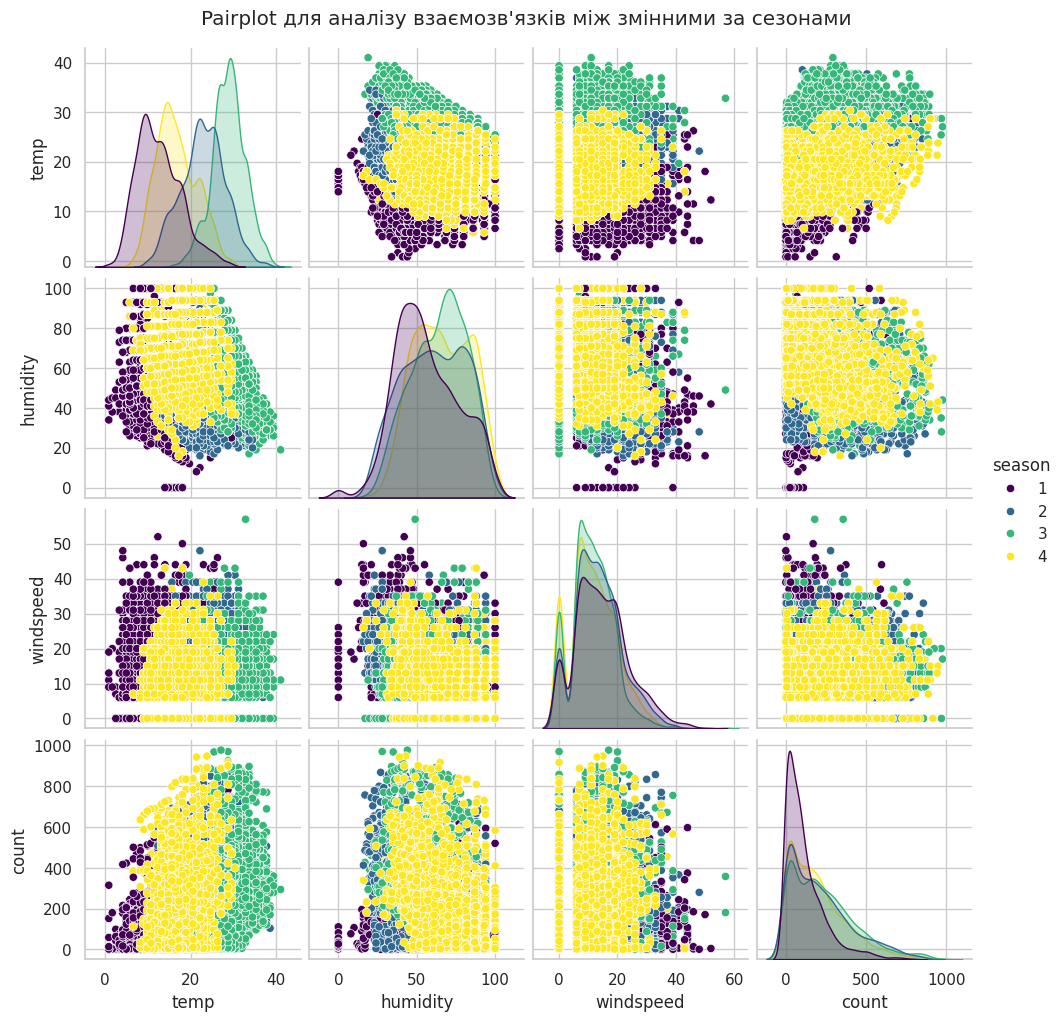

In [ ]:

# Побудова pairplot
# Вибір потрібних колонок
cols = ['temp', 'humidity', 'windspeed', 'count', 'season']

# Створення pairplot
sns.pairplot(df[cols], hue='season', palette='viridis')
plt.suptitle('Pairplot для аналізу взаємозв\'язків між змінними за сезонами', y=1.02)
plt.show()


✅ ***Висновок:***
1. Найсильніший лінійний зв'язок спостерігається між temp (температурою) та count (загальною кількістю оренди). На графіку розсіювання (нижній лівий кут) видно, що зі збільшенням температури кількість оренди послідовно зростає, а точки утворюють виражений позитивний тренд.
2. Характеристикою, яка найбільше візуально відрізняється між кварталами (сезонами), є temp (температура). Якщо подивитися на діагональний графік розподілу для температури, видно чотири чітко розділені піки (кожен відповідає своєму кольору/сезону), що свідчить про те, що кожен сезон має свій виражений температурний діапазон. Інші характеристики, такі як вологість або швидкість вітру, мають більше перекриття між сезонами.


## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

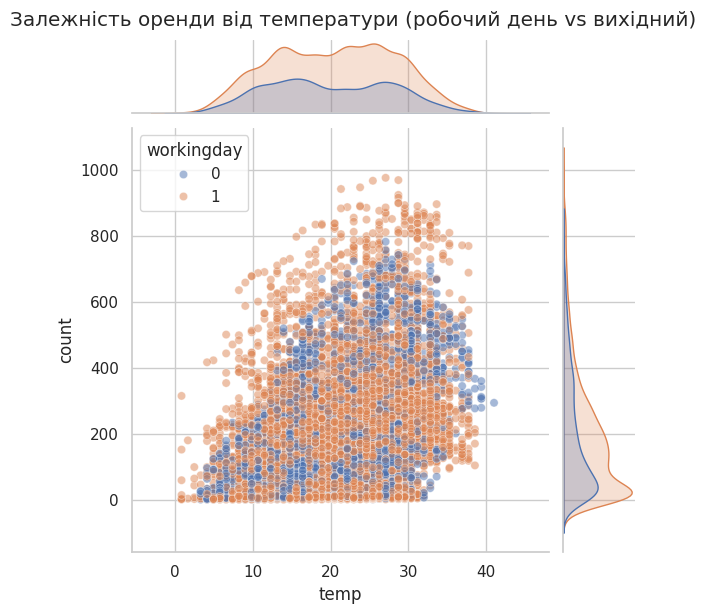

In [ ]:
# Побудова joint plot
sns.jointplot(data=df, x='temp', y='count', hue='workingday', kind='scatter', alpha=0.5)
plt.suptitle('Залежність оренди від температури (робочий день vs вихідний)', y=1.02)
plt.show()


✅***Висновок:***
1. Графіки по краях (маргінальні графіки) показують одномірний розподіл кожної зі змінних окремо.
Верхній графік (над віссю X) показує розподіл температури (temp), розбитий за робочими/неробочими днями.
Правий графік (біля осі Y) показує розподіл кількості оренди (count), також розбитий за робочими/неробочими днями.
Ці графіки допомагають візуально оцінити частоту появи різних значень для кожної змінної незалежно від іншої.

2. Так, різниця в поведінці користувачів помітна.
В основному полі розсіювання видно, що як у робочі, так і в неробочі дні люди орендують більше велосипедів при вищій температурі.
На маргінальному графіку count (правий бік) видно, що розподіл оренди у робочі дні (помаранчевий колір) має вищий пік і більшу щільність у діапазоні середньої та високої кількості оренд, ніж у неробочі дні (синій колір). Це означає, що в робочі дні частіше фіксується більша кількість орендованих велосипедів (імовірно, через регулярні поїздки на роботу).